## Датасет "Enron Email Dataset" появился в результате расследования крупнейшего корпоративного скандала в истории США — краха энергетической корпорации Enron Corporation в декабре 2001 года.

### Крах компании Enron (2001):
### Enron была одной из крупнейших энергетических компаний США.
#### --В 2001 году она обанкротилась из-за масштабных бухгалтерских махинаций и финансовых махинаций (энроновский скандал).
Это привело к уголовному расследованию.

#### --Изъятие электронных писем:
В ходе расследования Министерство юстиции США изъяло большое количество внутренних электронных писем сотрудников компании.
В основном переписка велась между руководителями, менеджерами и другими сотрудниками.

#### --Публикация данных (2003–2004):
В 2003 году Федеральная энергетическая регуляторная комиссия (FERC) опубликовала часть этой переписки в публичном доступе в рамках расследования.
В 2004 году Калифорнийский университет в Беркли и другие исследователи подготовили датасет из этих писем в более структурированном и пригодном для анализа виде.

## Что содержит датасет:
#### Более 500 000 писем.
#### Около 150 пользователей (в основном старшие сотрудники Enron).
#### Формат: папки «inbox», «sent», «deleted items» и другие.
#### Формат хранения: часто .mbox или структура папок.

### Зачем используется:
#### Enron dataset — один из немногих реальных и публичных больших корпоративных email-корпусов. Он стал золотым стандартом для:

#### --задач обработки естественного языка (NLP);

#### --анализов соцсетей, потоков коммуникаций;

#### --машинного обучения, в том числе для определения спама, тональности и пр.;

#### --изучения организационного поведения и коммуникации в компаниях.

## EDA

In [466]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string

In [467]:
df = pd.read_csv('../emails.csv')
df.shape

(5728, 2)

In [468]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [469]:
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [470]:
df.describe()

,spam
count,5728.000000
mean,0.238827
std,0.426404
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [471]:
df.isnull().sum()

text    0
spam    0
dtype: int64

In [472]:
ham = df[df['spam']==0]
spam =df[df['spam']==1]

In [473]:
spam

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
...,...,...
1363,Subject: are you ready to get it ? hello ! v...,1
1364,Subject: would you like a $ 250 gas card ? do...,1
1365,"Subject: immediate reply needed dear sir , i...",1
1366,Subject: wanna see me get fisted ? fist bang...,1


In [474]:
ham

,text,spam
1368,"Subject: hello guys , i ' m "" bugging you "" f...",0
1369,Subject: sacramento weather station fyi - - ...,0
1370,Subject: from the enron india newsdesk - jan 1...,0
1371,Subject: re : powerisk 2001 - your invitation ...,0
1372,Subject: re : resco database and customer capt...,0
...,...,...
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0


<Axes: xlabel='spam', ylabel='count'>

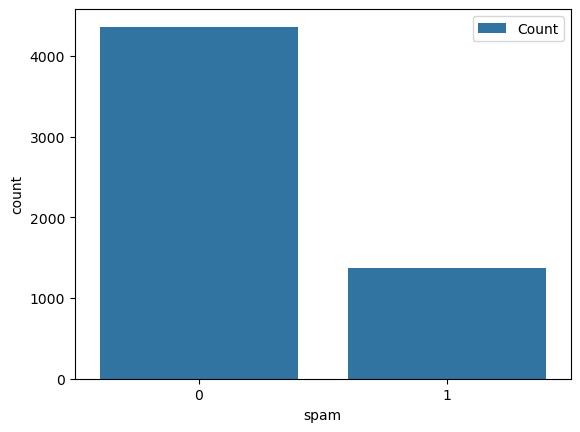

In [475]:
sns.countplot(x=df['spam'], label='Count')

## Видим что датасет несбалансирован, ham(4360raws)больше чем spam(1368raws)

In [476]:
df['text_length_words'] = df['text'].apply(lambda x: len(x.split()))

In [477]:
df['text_length_words'].describe()

count    5728.000000
mean      326.848638
std       418.777435
min         2.000000
25%       101.000000
50%       210.000000
75%       401.000000
max      8477.000000
Name: text_length_words, dtype: float64

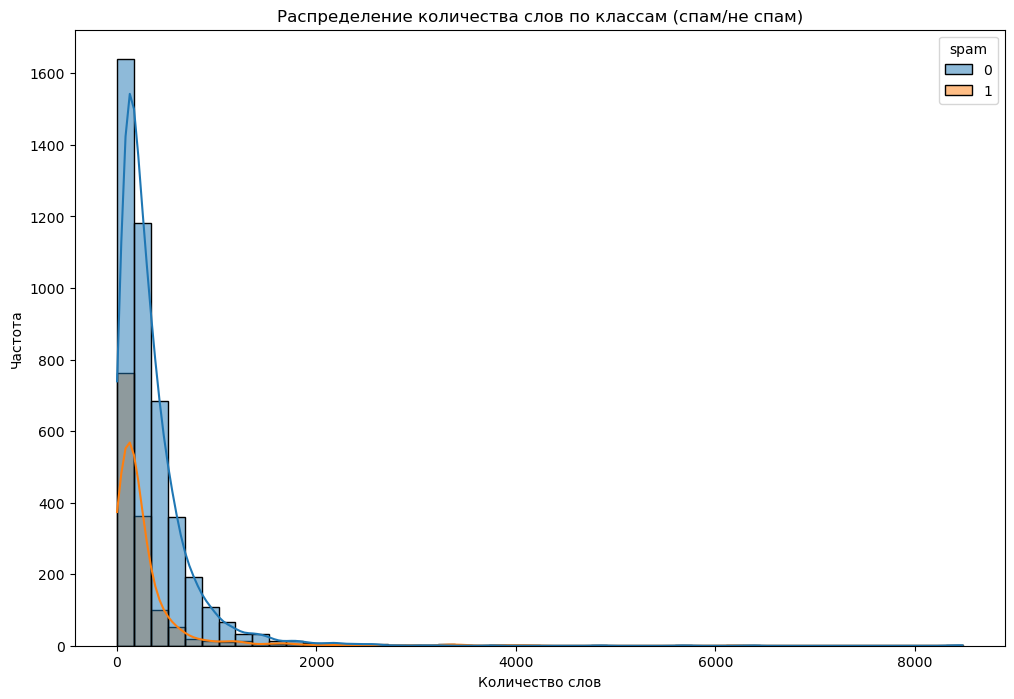

In [478]:
plt.figure(figsize=(12, 8))
sns.histplot(data=df, x='text_length_words', hue='spam', bins=50, kde=True)
plt.title("Распределение количества слов по классам (спам/не спам)")
plt.xlabel("Количество слов")
plt.ylabel("Частота")
plt.show()

## Выводы с графика:  Только по количеству слов трудно чётко отличить спам от не-спама.
#### 1. Большинство писем короткие — от 0 до ~500 слов.
#### 2. Спам и хэм распределены похоже, но:
#### Спам чуть чаще попадается с очень короткими письмами (в районе 0–100 слов).
#### Длинные письма (> 1000 слов) — редкость для обеих категорий.

In [479]:
# самое длинное сообщение 8477 слов
longest_msg = df.loc[df['text_length_words'].idxmax()]
print(longest_msg['text']) 
print("Длина:", longest_msg['text_length_words'])

Subject: from the enron india newsdesk - april 27 th newsclips  fyi news articles from indian press .  - - - - - - - - - - - - - - - - - - - - - - forwarded by sandeep kohli / enron _ development on 04 / 27 / 2001 08 : 24 am - - - - - - - - - - - - - - - - - - - - - - - - - - -  nikita varma  04 / 27 / 2001 07 : 51 am  to : nikita varma / enron _ development @ enron _ development  cc : ( bcc : sandeep kohli / enron _ development )  subject : from the enron india newsdesk - april 27 th newsclips  friday apr 27 2001 , http : / / www . economictimes . com / today / cmo 3 . htm  dpc board empowers md to cancel mseb contract  friday apr 27 2001 , http : / / www . economictimes . com / today / 27 compl 1 . htm  mseb pays rs 134 cr under ' protest ' to dpc  friday , april 27 , 001 , http : / / www . businessstandard . com / today / economy 4 . asp ? menu = 3  enron india md authorised to terminate ppa  friday , april 27 , 2001 , http : / / www . financialexpress . com / fe 20010427 / topl . h

In [480]:
top_long = df.sort_values(by='text_length_words', ascending=False)

In [481]:
top_long

,text,spam,text_length_words
2650,Subject: from the enron india newsdesk - april...,0,8477
1380,Subject: from the enron india newsdesk - april...,0,8364
2338,Subject: from the enron india newsdesk - april...,0,6348
536,Subject: make thousands just sending emails . ...,1,6129
2560,Subject: from the enron india newsdesk - may 5...,0,5689
...,...,...,...
5405,Subject: proposal - kevin kindall,0,5
568,Subject: . jif .,1,4
2567,Subject: this hurricane elana,0,4
2263,Subject: elena chilkina hi,0,4


In [482]:
top_long20 = df[df['text_length_words'] >= 8000]

In [483]:
for i, row in top_long20.sort_values(by='text_length_words').iterrows():
    print(f"\n- Сообщение {i} (Длина: {row['text_length_words']}) -\n")
    print(row['text'])


- Сообщение 1380 (Длина: 8364) -

Subject: from the enron india newsdesk - april 27 th newsclips  fyi news articles from indian press .  - - - - - - - - - - - - - - - - - - - - - - forwarded by sandeep kohli / enron _ development on  04 / 27 / 2001 08 : 24 am - - - - - - - - - - - - - - - - - - - - - - - - - - -  nikita varma  04 / 27 / 2001 07 : 51 am  to : nikita varma / enron _ development @ enron _ development  cc : ( bcc : sandeep kohli / enron _ development )  subject : from the enron india newsdesk - april 27 th newsclips  friday apr 27 2001 , http : / / www . economictimes . com / today / cmo 3 . htm  dpc board empowers md to cancel mseb contract  friday apr 27 2001 , http : / / www . economictimes . com / today / 27 compl 1 . htm  mseb pays rs 134 cr under ' protest ' to dpc  friday , april 27 , 001 ,  enron india md authorised to terminate ppa  friday , april 27 , 2001 , http : / / www . financialexpress . com / fe 20010427 / topl . html  foreign lenders slam brakes on disbu

In [484]:
shortest_msgs = df.sort_values(by='text_length_words', ascending=True)
shortest_msgs

,text,spam,text_length_words
1991,Subject: fyi,0,2
2263,Subject: elena chilkina hi,0,4
568,Subject: . jif .,1,4
2567,Subject: this hurricane elana,0,4
5405,Subject: proposal - kevin kindall,0,5
...,...,...,...
2560,Subject: from the enron india newsdesk - may 5...,0,5689
536,Subject: make thousands just sending emails . ...,1,6129
2338,Subject: from the enron india newsdesk - april...,0,6348
1380,Subject: from the enron india newsdesk - april...,0,8364


In [485]:
short_msgs_top20 = df[df['text_length_words'] <= 20]

In [486]:
for i, row in short_msgs_top20.sort_values(by='text_length_words').iterrows():
    print(f"\n- Сообщение {i} (Длина: {row['text_length_words']}) -\n")
    print(row['text'])


- Сообщение 1991 (Длина: 2) -

Subject: fyi 

- Сообщение 568 (Длина: 4) -

Subject: . jif  . 

- Сообщение 2263 (Длина: 4) -

Subject: elena chilkina  hi

- Сообщение 2567 (Длина: 4) -

Subject: this  hurricane elana 

- Сообщение 5405 (Длина: 5) -

Subject: proposal  - kevin kindall

- Сообщение 2009 (Длина: 6) -

Subject: congratulations - well deserved . 

- Сообщение 3354 (Длина: 6) -

Subject: itinerary  phelim ,  fyi  vince

- Сообщение 631 (Длина: 6) -

Subject: discreet penis enlargement 4623  4623

- Сообщение 3806 (Длина: 7) -

Subject: congratulations on your promotion . lou 

- Сообщение 3035 (Длина: 7) -

Subject: re : research allocation  thank you

- Сообщение 4398 (Длина: 7) -

Subject: re : rankings  thank you .

- Сообщение 2841 (Длина: 7) -

Subject: your approval is requested  thank you

- Сообщение 4320 (Длина: 7) -

Subject: password  login kkindal  password marketcredit !

- Сообщение 4158 (Длина: 9) -

Subject: re : requests for help  thanks vince .

- Сообщен

## Извлекаем дату из первых строк сообщения

In [487]:
# Извлечение даты и приведение к datetime
from dateutil import parser

def extract_date(text):
    try:
        first_line = text.splitlines()[0]  #БерёМ первую строку письма ([0]), потому что именно в первой строке чаще всего находится дата отправки.
        return parser.parse(first_line, fuzzy=True) #Парсер будет игнорировать лишние слова и символы, которые не относятся к дате
    except:
        return pd.NaT

In [488]:
df['email_date'] = df['text'].apply(extract_date)
df['email_date'] = pd.to_datetime(df['email_date'], errors='coerce')  

In [489]:
print("Распознано дат:", df['email_date'].notna().sum())

Распознано дат: 549


In [490]:
# Группировка по месяцам
df_with_date = df.dropna(subset=['email_date']).copy() #письма без даты
df_with_date['year_month'] = df_with_date['email_date'].dt.to_period('M').astype(str) 

In [1]:
df_with_date = df_with_date[
    (df_with_date['email_date'].dt.year >= 1998) &
    (df_with_date['email_date'].dt.year <= 2002)]

NameError: name 'df_with_date' is not defined

In [492]:
date_spam_counts = (
    df_with_date
    .groupby([df_with_date['year_month'].astype(str), 'spam'])  # Convert to string here
    .size()
    .unstack(fill_value=0)
)

date_spam_counts.columns = ['Ham', 'Spam']
date_spam_counts = date_spam_counts.astype(int)

            Ham  Spam
year_month           
May 1995      1     0
Jul 1995      2     0
May 1996      0     1
Feb 1998      1     0
Jul 1998      2     0
Jul 1999      1     1
Sep 1999      1     0
Jan 2000      8     0
Feb 2000      4     0
Mar 2000      1     0
Apr 2000      4     0
May 2000      1     0
Jun 2000      3     0
Jul 2000      9     1
Aug 2000      4     0
Sep 2000      2     0
Oct 2000      1     0
Nov 2000      2     0
Dec 2000      2     0
Jan 2001      5     0


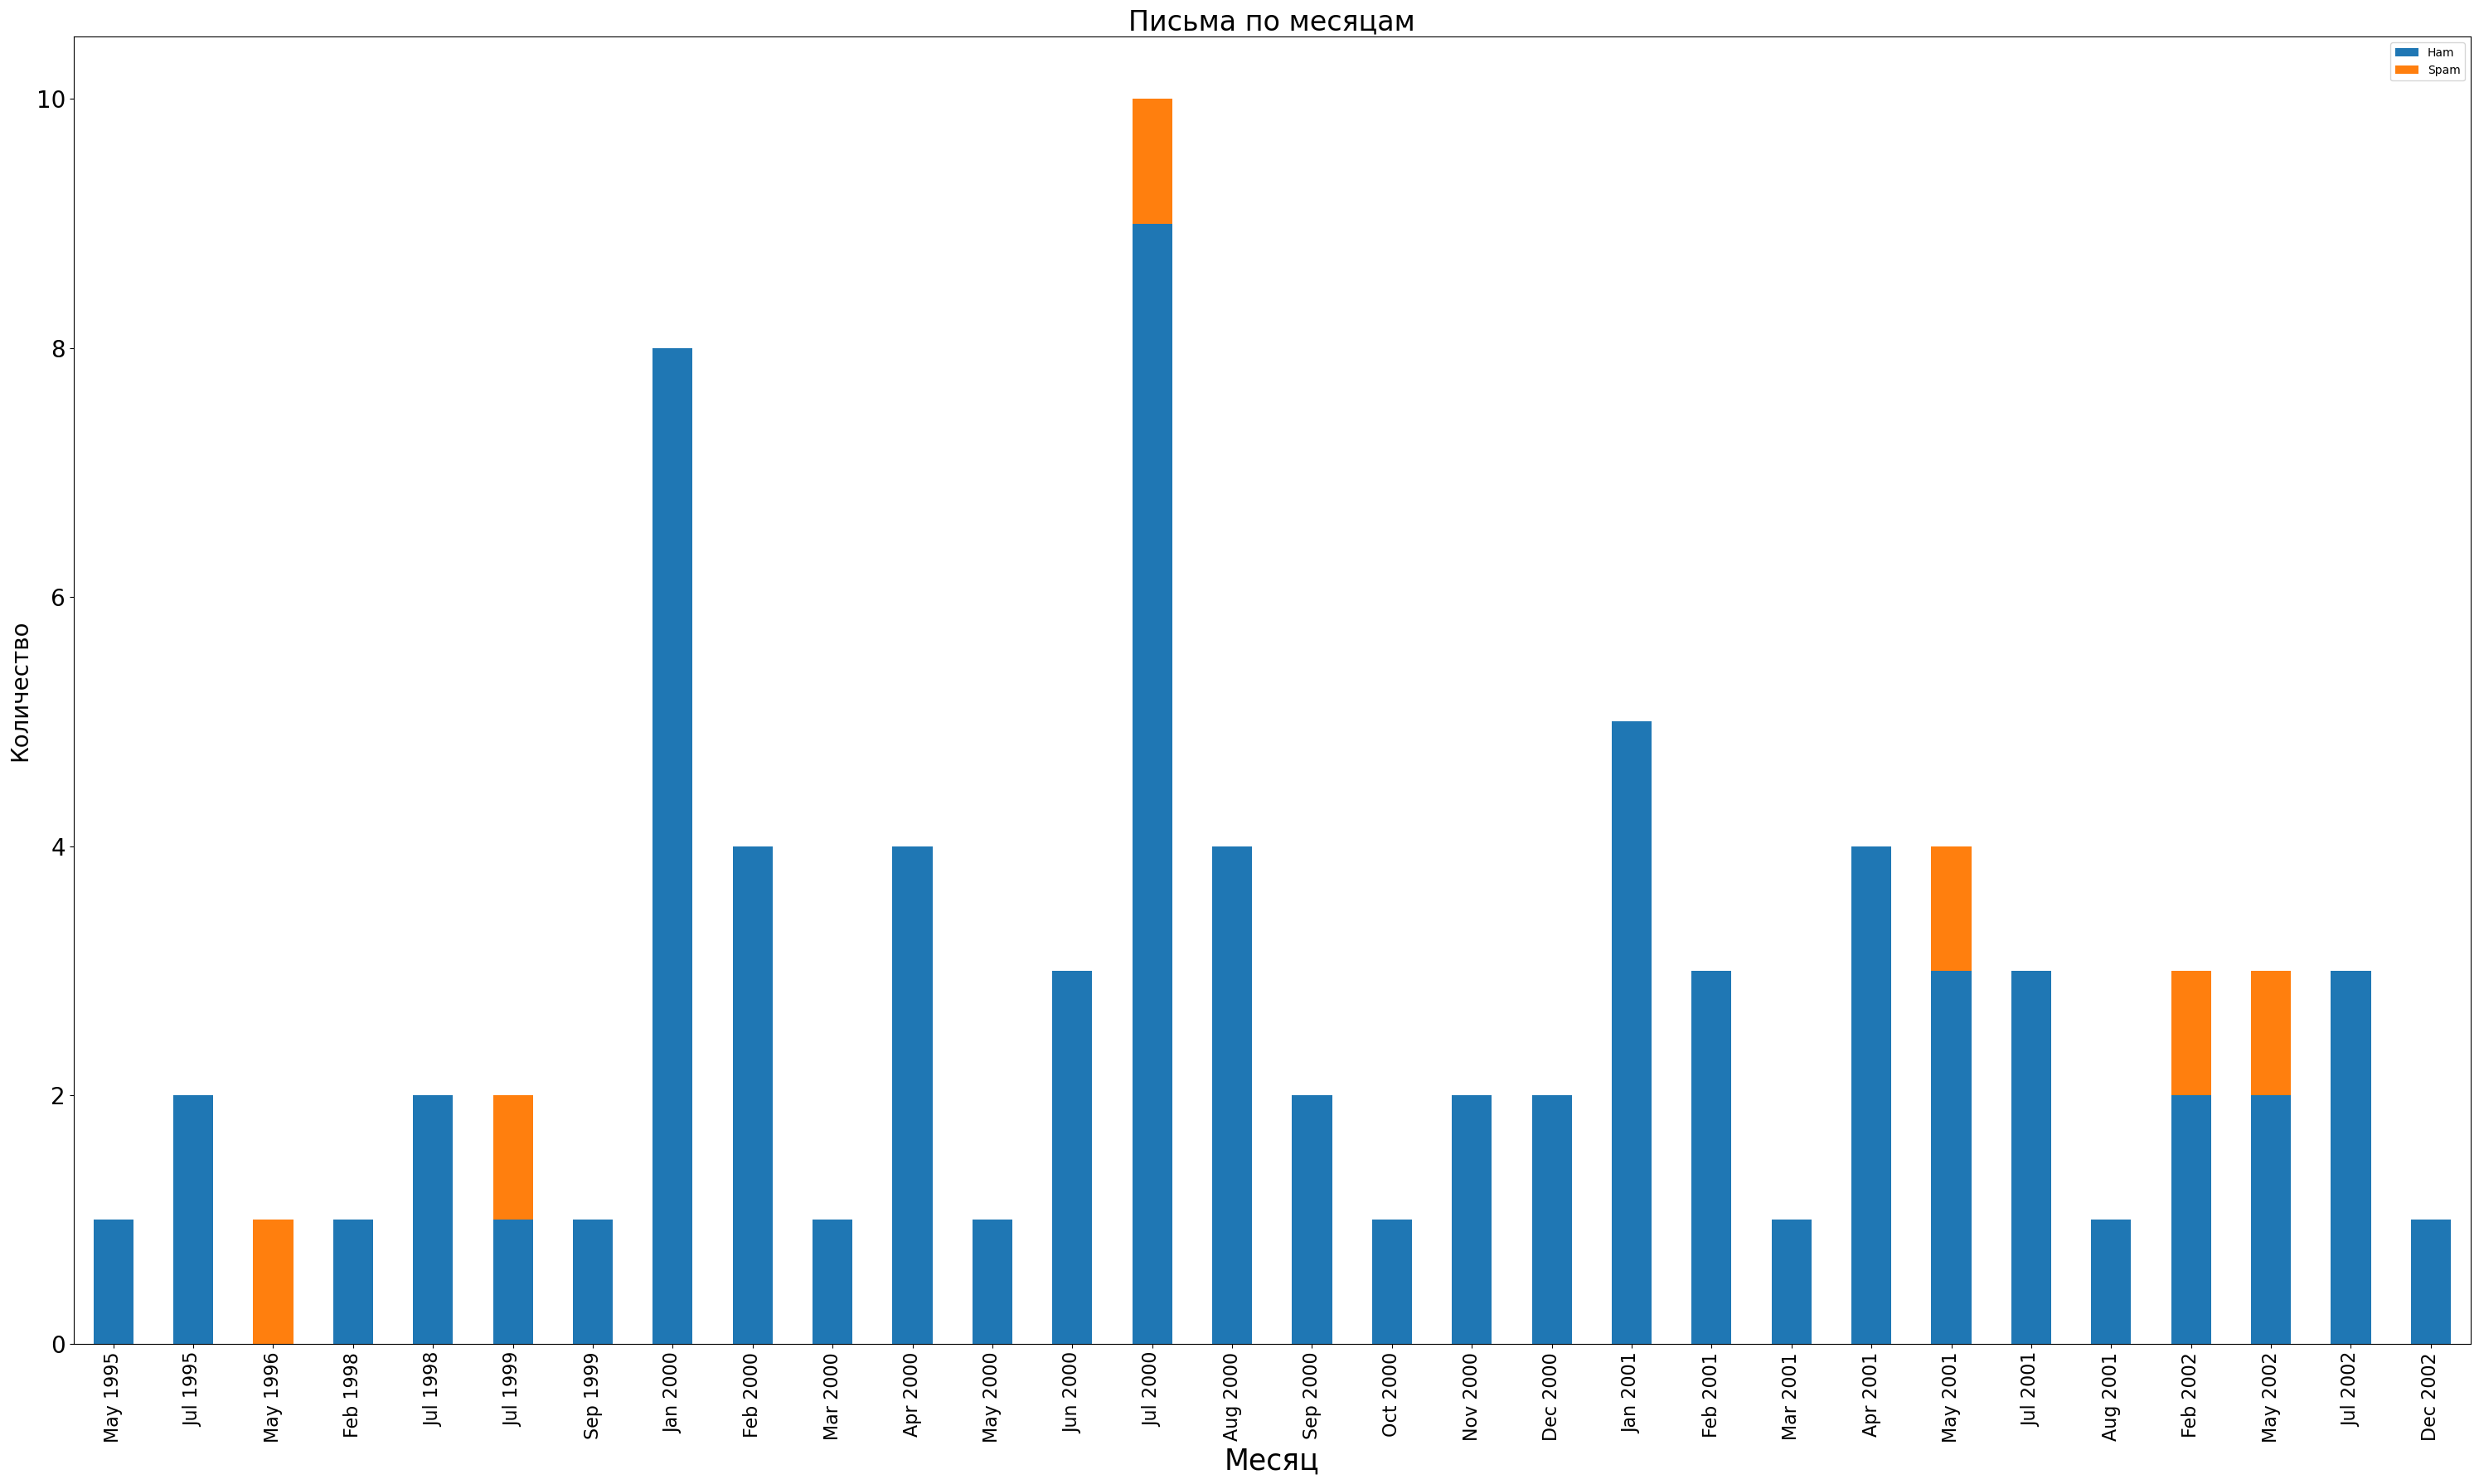

In [493]:
# Читаемые метки индекса
date_spam_counts.index = pd.to_datetime(date_spam_counts.index).strftime('%b %Y')

print(date_spam_counts.head(20))

date_spam_counts.plot(kind='bar', stacked=True, figsize=(30, 18))
plt.title("Письма по месяцам", fontsize=24)
plt.xlabel("Месяц", fontsize=25)
plt.ylabel("Количество", fontsize=20)
plt.xticks(rotation=90, fontsize=16)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.show()

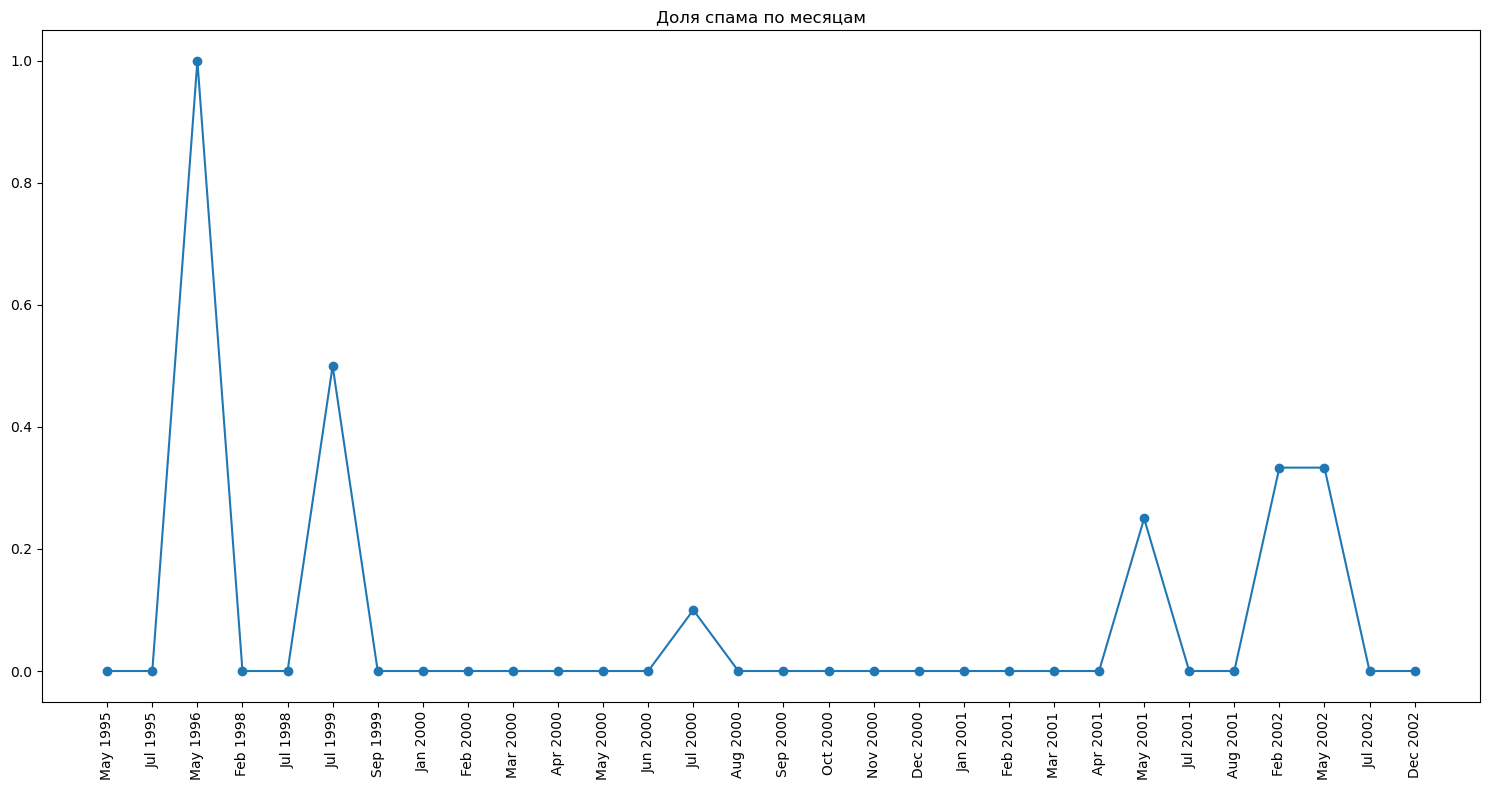

In [494]:
# Доля спама
prop = date_spam_counts.div(date_spam_counts.sum(axis=1), axis=0)
plt.figure(figsize=(15,8))
plt.plot(prop.index, prop.get('Spam', [0]*len(prop)), marker='o')
plt.title("Доля спама по месяцам")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [495]:
emails_2002 = df_with_date[df_with_date['email_date'].dt.year == 2002]

In [496]:
for i, row in emails_2002.iterrows():
    print(f"\nДата: {row['email_date']}")
    print(row['text'])


Дата: 2002-02-01 23:00:00
Subject: please help my child  dear sir / mam ,  i have send this email in order to recive some help .  i am a single father from italy and i have a big problem . my 2 year child is cancer sick and i need money to treat him . i don ' t ask for lots off money but as much as you want : 1 $ 2 $ . . . . i will be pleased .  this is my sweet boy nely :  nely pictures  the pics say all the things .  if you have a hart and you are a father then please this is my paypal email address : david _ horatiul 23 @ yahoo . com .  thank you and i ' m very sorry for this email , but i need help .  have a nice day and good bless you !  please help my boy ! ! ! 

Дата: 2002-05-02 00:00:00
Subject: delivery status notification  - these recipients of your message have been processed by the mail server :  antonioacm @ zipmail . com . br ; failed ; 5 . 2 . 2 ( mailbox full )

Дата: 2002-02-01 00:00:00
Subject: term paper  dr . kaminski ,  attached please find a copy of our term pape

# Подтверждение из официальных источников:
## "The Enron Corpus consists of 500,000 emails generated by about 150 Enron employees. The data was collected during the investigation into Enron's collapse and includes emails from 1998 until early 2002." — источник: Carnegie Mellon University (создатель датасета)

## Почему есть письма за 2002 год, если Enron закрыли в 2001?
Официально компания Enron объявила о банкротстве в декабре 2001 года, но:
Полный процесс ликвидации и работы по делам компании продолжался еще несколько лет (вплоть до 2004–2007 годов).
Некоторые подразделения продолжали работать для завершения контрактов, юридических процессов, распродажи активов, аудитов и расследований.
Некоторые внутренние сервисы Enron продолжали функционировать, пока шло банкротство.

## Попытка разделить сообщения на отправленные и полученные, затем узнать в каких больше спама

In [497]:
# Простейший способ определения
def is_sent_simple(text):
    if pd.isna(text):
        return False
    text_lower = text.lower()
    return 'to:' in text_lower or 'sent to' in text_lower

def is_received_simple(text):
    if pd.isna(text):
        return False
    text_lower = text.lower()
    return ('from:' in text_lower) or ('forwarded by' in text_lower)

# Добавляем в датафрейм
df['is_sent'] = df['text'].apply(is_sent_simple)
df['is_received'] = df['text'].apply(is_received_simple)

# Проверяем сколько чего
print('Полученные письма:', df['is_received'].sum())
print('Отправленные письма:', df['is_sent'].sum())

# Смотрим примеры отправленных
print("\nПримеры отправленных писем:")
print(df[df['is_sent'] == True]['text'].head(3))

# Смотрим примеры полученных
print("\nПримеры полученных писем:")
print(df[df['is_received'] == True]['text'].head(3))

Полученные письма: 1052
Отправленные письма: 153

Примеры отправленных писем:
10    Subject: las vegas high rise boom  las vegas i...
91    Subject: use this handy interest calculator to...
94    Subject: outstanding opportunities for " premi...
Name: text, dtype: object

Примеры полученных писем:
1369    Subject: sacramento weather station  fyi  - - ...
1370    Subject: from the enron india newsdesk - jan 1...
1372    Subject: re : resco database and customer capt...
Name: text, dtype: object


In [498]:
sent_spam_counts = df[df['is_sent'] == True]['spam'].value_counts()

print("Отправленные письма:")
print(f"Не спам (Ham): {sent_spam_counts.get(0, 0)}")
print(f"Спам (Spam): {sent_spam_counts.get(1, 0)}")

Отправленные письма:
Не спам (Ham): 89
Спам (Spam): 64


In [499]:
received_spam_counts = df[df['is_received'] == True]['spam'].value_counts()

print("\nПолученные письма:")
print(f"Не спам (Ham): {received_spam_counts.get(0, 0)}")
print(f"Спам (Spam): {received_spam_counts.get(1, 0)}")


Полученные письма:
Не спам (Ham): 1052
Спам (Spam): 0


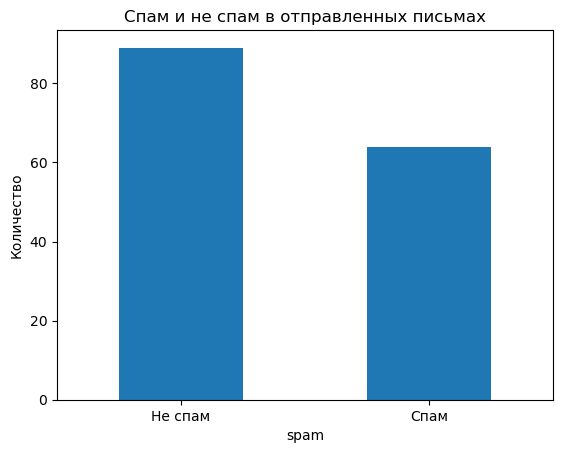

In [500]:
sent_spam_counts.plot(kind='bar', title='Спам и не спам в отправленных письмах')
plt.xticks([0, 1], ['Не спам', 'Спам'], rotation=0)
plt.ylabel('Количество')
plt.show()

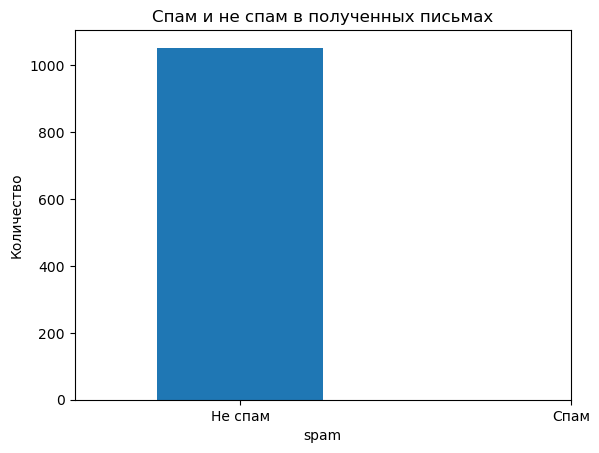

In [501]:
received_spam_counts.plot(kind='bar', title='Спам и не спам в полученных письмах')
plt.xticks([0, 1], ['Не спам', 'Спам'], rotation=0)
plt.ylabel('Количество')
plt.show()

In [502]:
df

,text,spam,text_length_words,email_date,is_sent,is_received
0,Subject: naturally irresistible your corporate...,1,324,NaT,False,False
1,Subject: the stock trading gunslinger fanny i...,1,89,NaT,False,False
2,Subject: unbelievable new homes made easy im ...,1,87,NaT,False,False
3,Subject: 4 color printing special request add...,1,98,NaT,False,False
4,"Subject: do not have money , get software cds ...",1,52,NaT,False,False
...,...,...,...,...,...,...
5723,Subject: re : research and development charges...,0,297,NaT,False,True
5724,"Subject: re : receipts from visit jim , than...",0,244,NaT,False,False
5725,Subject: re : enron case study update wow ! a...,0,515,NaT,False,True
5726,"Subject: re : interest david , please , call...",0,276,NaT,False,True


## TEXT CLEANING

In [503]:
all_text = " ".join(df["text"].astype(str))

In [504]:
# Перевожу к нижнему регистру и убираю знаки препинания
all_text = all_text.lower()
all_text = all_text.translate(str.maketrans("", "", string.punctuation))

In [505]:
words = all_text.split()

In [506]:
from collections import Counter
word_freq = Counter(words)

In [507]:
word_freq.most_common(20)

[('the', 50110),
 ('to', 41736),
 ('and', 27478),
 ('of', 23757),
 ('a', 19945),
 ('you', 19154),
 ('in', 17975),
 ('i', 17421),
 ('for', 16696),
 ('enron', 13382),
 ('on', 12719),
 ('is', 12595),
 ('ect', 11418),
 ('subject', 10179),
 ('this', 10031),
 ('that', 9291),
 ('your', 9274),
 ('be', 9262),
 ('with', 8853),
 ('we', 8688)]

In [508]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

filtered_words = [w for w in words if w not in ENGLISH_STOP_WORDS]
filtered_freq = Counter(filtered_words)
filtered_freq.most_common(20)

[('enron', 13382),
 ('ect', 11418),
 ('subject', 10179),
 ('vince', 8532),
 ('s', 6506),
 ('hou', 5577),
 ('com', 5442),
 ('2000', 4967),
 ('kaminski', 4770),
 ('cc', 3896),
 ('j', 3764),
 ('1', 3442),
 ('pm', 3286),
 ('2001', 3089),
 ('2', 2936),
 ('time', 2733),
 ('research', 2733),
 ('10', 2618),
 ('thanks', 2585),
 ('know', 2545)]

In [509]:
df.isnull().sum()

text                    0
spam                    0
text_length_words       0
email_date           5179
is_sent                 0
is_received             0
dtype: int64

In [510]:
df

,text,spam,text_length_words,email_date,is_sent,is_received
0,Subject: naturally irresistible your corporate...,1,324,NaT,False,False
1,Subject: the stock trading gunslinger fanny i...,1,89,NaT,False,False
2,Subject: unbelievable new homes made easy im ...,1,87,NaT,False,False
3,Subject: 4 color printing special request add...,1,98,NaT,False,False
4,"Subject: do not have money , get software cds ...",1,52,NaT,False,False
...,...,...,...,...,...,...
5723,Subject: re : research and development charges...,0,297,NaT,False,True
5724,"Subject: re : receipts from visit jim , than...",0,244,NaT,False,False
5725,Subject: re : enron case study update wow ! a...,0,515,NaT,False,True
5726,"Subject: re : interest david , please , call...",0,276,NaT,False,True


In [511]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['text']) 

In [512]:
X.shape

(5728, 37303)

In [513]:
from sklearn.naive_bayes import MultinomialNB

NB_classifier = MultinomialNB()
label = df['spam'].values
NB_classifier.fit(X, label)

MultinomialNB()

In [514]:
y = label

In [515]:
from sklearn.model_selection import train_test_split
X_train, X_test ,y_train, y_test = train_test_split(X, y, test_size=0.3)
X_train.shape, X_test.shape

((4009, 37303), (1719, 37303))

In [516]:
test_sample =  ["I've been searching for the right words to thank you for this breather."]

In [517]:
test_sample_countvectorizer = vectorizer.transform(test_sample)

In [518]:
test_predict = NB_classifier.predict(test_sample_countvectorizer)
test_predict

array([1])

In [519]:
from sklearn.metrics import classification_report ,confusion_matrix

<Axes: >

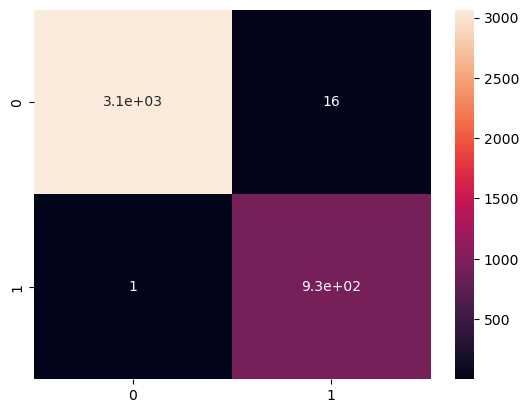

In [520]:
y_pred_train = NB_classifier.predict(X_train)
cm = confusion_matrix(y_train, y_pred_train)
sns.heatmap(cm, annot=True)

<Axes: >

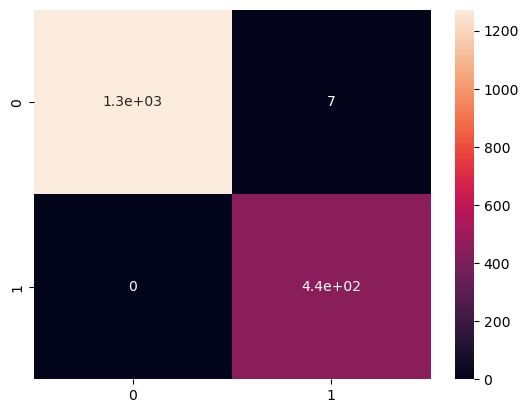

In [521]:
y_pred_test = NB_classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True)

In [522]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1279
           1       0.98      1.00      0.99       440

    accuracy                           1.00      1719
   macro avg       0.99      1.00      0.99      1719
weighted avg       1.00      1.00      1.00      1719



In [523]:
from sklearn.model_selection import train_test_split
X_train, X_test ,y_train, y_test = train_test_split(X, y, test_size=0.3)
X_train.shape, X_test.shape

((4009, 37303), (1719, 37303))

In [524]:
from sklearn.linear_model import LogisticRegression

In [525]:
logreg = LogisticRegression()
label = df['spam'].values
logreg.fit(X_train, y_train)

LogisticRegression()

In [526]:
tests =  ["I've been searching for"]

In [527]:
tests_countvectorizer = vectorizer.transform(tests)

In [528]:
predict_test = NB_classifier.predict(tests_countvectorizer)
predict_test

array([1])

<Axes: >

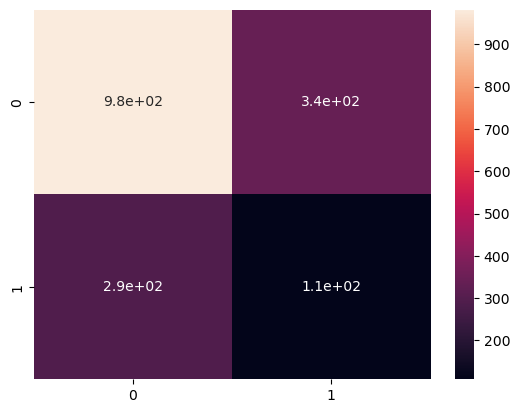

In [529]:
y_pred_train = logreg.predict(X_train)
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True)

<Axes: >

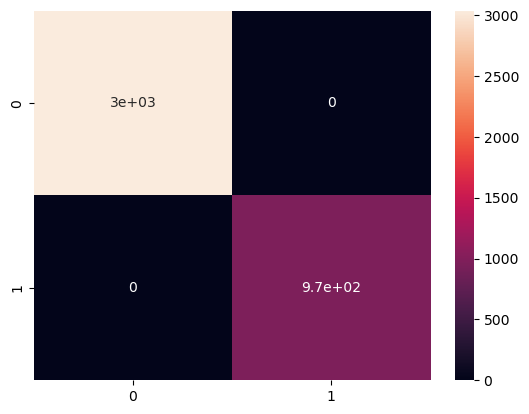

In [530]:
y_pred_train = logreg.predict(X_train)
cm = confusion_matrix(y_train, y_pred_train)
sns.heatmap(cm, annot=True)

In [531]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.77      0.74      0.76      1321
           1       0.24      0.27      0.26       398

    accuracy                           0.63      1719
   macro avg       0.51      0.51      0.51      1719
weighted avg       0.65      0.63      0.64      1719

